# Forecast quality and revenue under a fixed pricing policy

This notebook replaces the original notebook's model/revenue evidence for this review. It leaves its data preparation untouched and reads its existing expanded-booking cache. It does not establish production readiness or beat actual human forecasts.

**Question:** Does a Random Forest selected on earlier weeks outperform an explicit planning rule on later weeks, and does that reduce the signed revenue gap to perfect information passed through the same policy?

**Design fixed before this run:** last 16 complete weeks; horizons 1 and 4 weeks; expanding history; model and flight-feature selection on 3 earlier origins; recent four-week mean primary baseline and last observed week secondary baseline. The evaluated data have been explored previously, so this is a retrospective repair, not a pristine prospective test. Outcomes from a completed test week may legitimately enter training at a later issue date. Hyperparameters stay frozen.

**Policy boundary:** the supplied threshold rule is an illustrative stand-in for another team's independent pricing model. The actual external model has not been supplied. Every forecast receives identical pricing rules and scenario assumptions. Perfect information through that same policy is distinct from the best-price oracle. Signed gaps can be negative.


In [1]:
from pathlib import Path
from forecast_validation import EvaluationConfig, load_reference_panel, run_evaluation
analysis_dir = Path.cwd()
bookings_cache = analysis_dir / 'temp_csv' / 'final_bookings_df.csv'
flights_csv = analysis_dir.parent / 'raw_data' / 'flights_sample.csv'
output_dir = analysis_dir / 'reports' / 'validated_forecast_v1'
config = EvaluationConfig()
print(config)


EvaluationConfig(horizons=(1, 4), test_weeks=16, seed=42, trees=150, reference_price_per_space_day=20.0, elasticities=(-0.5, -1.0, -1.2, -1.5, -2.0), capacity_scales=(1.0, 1.25, 1.5))


## Target and information boundary

The target is the sum of daily occupied spaces over a complete Monday-Sunday week, in **occupied space-days**. The existing cache determines the target. No contemporary booking totals, revenue or target-period realized passengers enter the predictor. Features use only completed weeks; calendar features are known in advance. Flight inputs assume end-of-week availability, which needs checking against real reporting delays. Missing cache rows count as zero; this inherits the original target's completeness assumptions.

The cohort includes parks with at least 8 positive weeks by the earliest evaluation origin. Capacity is a frozen historical-peak proxy, never claimed as measured capacity.


In [2]:
panel, daily, provenance = load_reference_panel(bookings_cache, flights_csv)
print(provenance)
print('Panel rows:', len(panel))
print(panel.head().to_string(index=False))


{'flight_rows': 79624, 'flight_start': '2023-01-01', 'flight_end': '2024-01-01', 'missing_terminal_flight_rows': 0, 'complete_weeks': 52, 'target_unit': 'occupied space-days per car park per week', 'target_provenance': 'Existing expanded-booking cache; upstream preparation inherited, not re-audited.', 'zero_assumption': 'Absence of cache rows is treated as zero occupancy; operational completeness not established.'}
Panel rows: 884
terminal carpark_name week_start  occupancy  passengers  flights
      T1     carpark1 2023-01-02        560     65029.0      422
      T1     carpark1 2023-01-09       2107     55339.0      359
      T1     carpark1 2023-01-16       2803     55859.0      356
      T1     carpark1 2023-01-23       3772     57727.0      358
      T1     carpark1 2023-01-30       4217     63944.0      380


## Run the locked experiment

The search is limited to the Random Forest family, with and without past-flight features. Selection uses development MAE, not evaluation revenue. It does not claim to select the best possible algorithm. All predictions, feature selections, input hashes, versions and forecast origins are saved for audit.


In [3]:
metrics, revenue_summary, manifest = run_evaluation(
    panel, daily, output_dir, config,
    source_paths=[bookings_cache, flights_csv], provenance=provenance,
)
print(metrics.to_string(index=False))
print('Evaluation:', manifest['test_start'], 'through', manifest['test_end'])
print('Eligible parks:', len(manifest['cohort']))


Horizon 1: selected {'include_flights': True, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 1.0, 'development_mae': 272.75840690636534}
Horizon 4: selected {'include_flights': False, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 1.0, 'development_mae': 829.6711476184486}
 horizon_weeks                 method         mae        rmse       r2  wape_pct       bias  p95_absolute_error  park_weeks
             1     Recent 4-week mean  699.963867 1170.872398 0.917697 15.340295 321.745117         2670.562500         256
             1     Last observed week  462.648438  801.128072 0.961470 10.139328  65.234375         1641.750000         256
             1 Selected Random Forest  489.433668  808.105657 0.960796 10.726349 105.166185         1878.657523         256
             4     Recent 4-week mean 1151.518555 1834.685275 0.797921 25.236494 845.916992         4701.187500         256
             4     Last observed week  996.621094 1595.835384 0.847111 21.841786 593.00

## Revenue scenarios, not measured commercial returns

Observed space-days are assumed to be unconstrained demand at GBP20 per space-day. Elasticities and capacity scales are hypothetical and shared across methods. Weekly aggregation omits intraday capacity, stays already booked, costs and customer substitution. This estimates conditional revenue, not profit, savings or a causal return from deployment. Results must never be summed across forecast horizons.

The same-policy perfect-information gap measures the effect of replacing the forecast under a frozen policy. The price oracle additionally chooses the best allowed action using actual demand. Neither proves that the illustrative pricing policy is economically optimal. A constant-price comparator is included.


In [4]:
default_scenario = revenue_summary.loc[
    (revenue_summary['elasticity'] == -1.2) & (revenue_summary['capacity_scale'] == 1.0)
]
print(default_scenario.to_string(index=False))
print()
print('Sensitivity of the selected Random Forest:')
print(revenue_summary.loc[revenue_summary['method'] == 'Selected Random Forest',
    ['horizon_weeks', 'capacity_scale', 'elasticity', 'uplift_pct', 'signed_gap_to_perfect_same_policy']
].to_string(index=False))


 horizon_weeks  capacity_scale  elasticity                           method      revenue  same_policy_perfect_revenue  price_oracle_revenue  signed_gap_to_perfect_same_policy  regret_to_price_oracle  action_agreement  evaluated_park_weeks  baseline_revenue    uplift_gbp  uplift_pct
             1             1.0        -1.2           Always reference price 2.331368e+07                 2.318411e+07          2.392889e+07                     -129570.371587            6.152084e+05          0.417969                   256      2.299582e+07 317863.841688    1.382268
             1             1.0        -1.2               Last observed week 2.317124e+07                 2.318411e+07          2.392889e+07                       12870.337383            7.576491e+05          0.800781                   256      2.299582e+07 175423.132718    0.762848
             1             1.0        -1.2 Perfect information, same policy 2.318411e+07                 2.318411e+07          2.392889e+07            

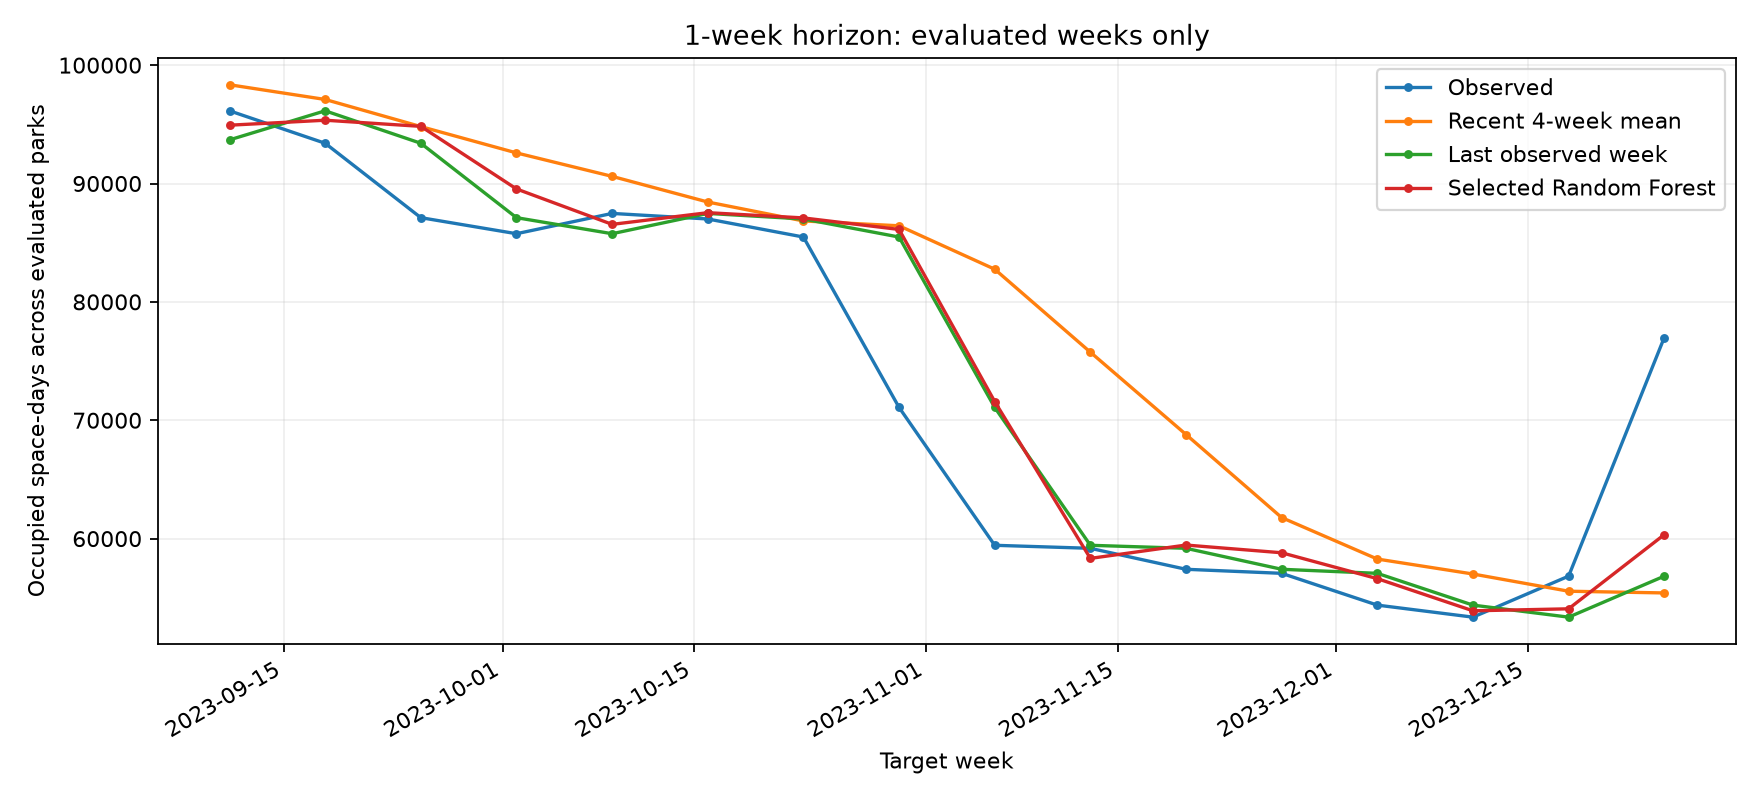

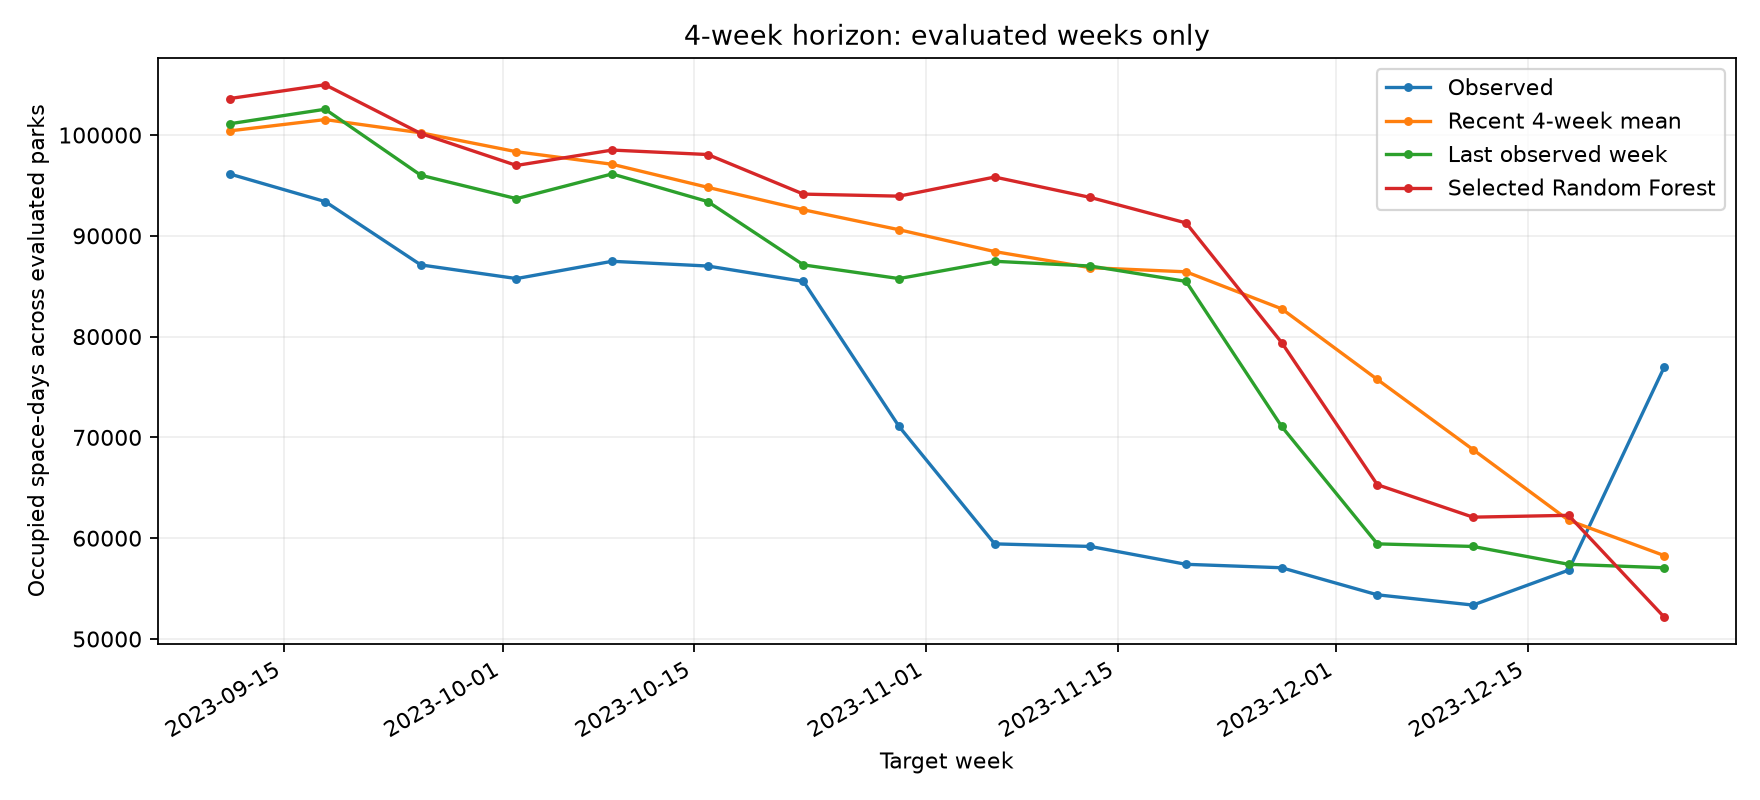

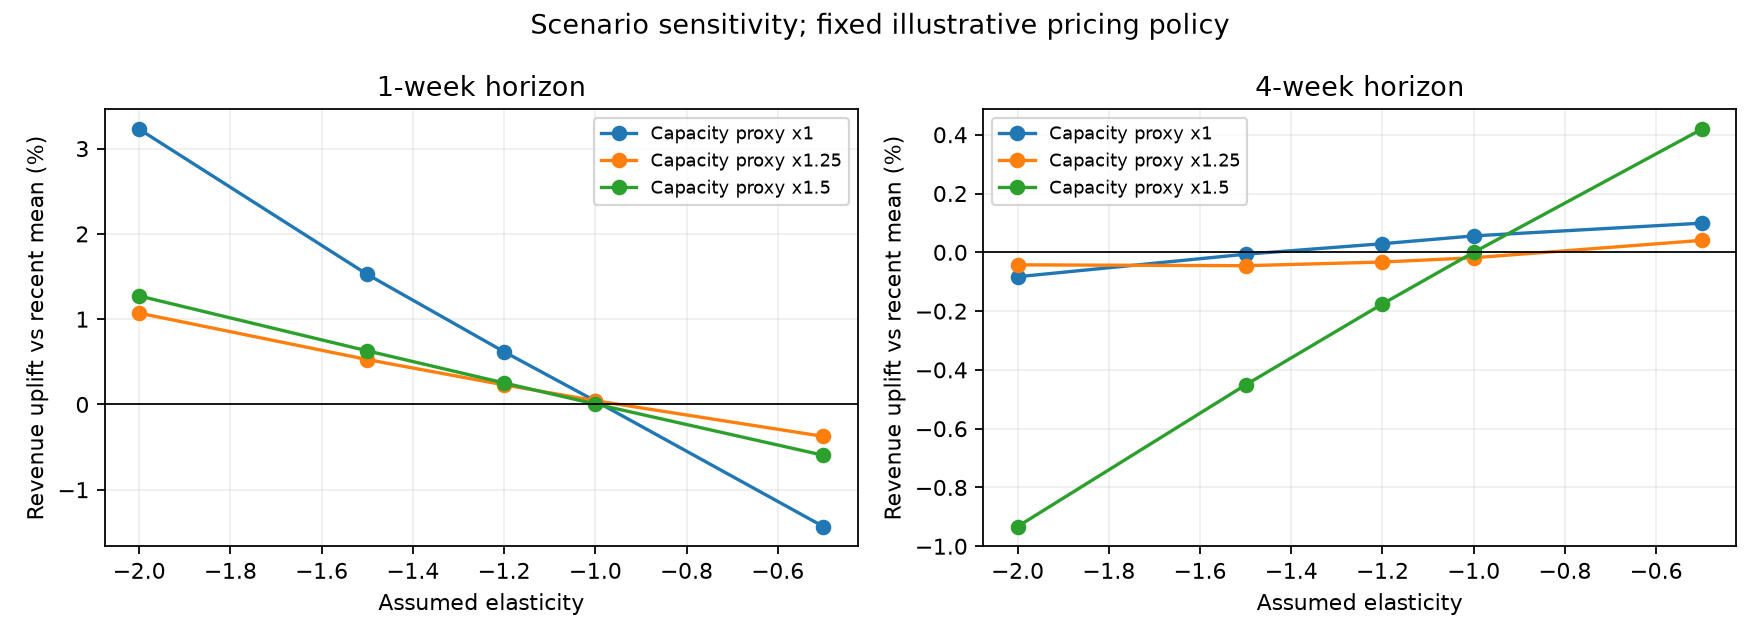

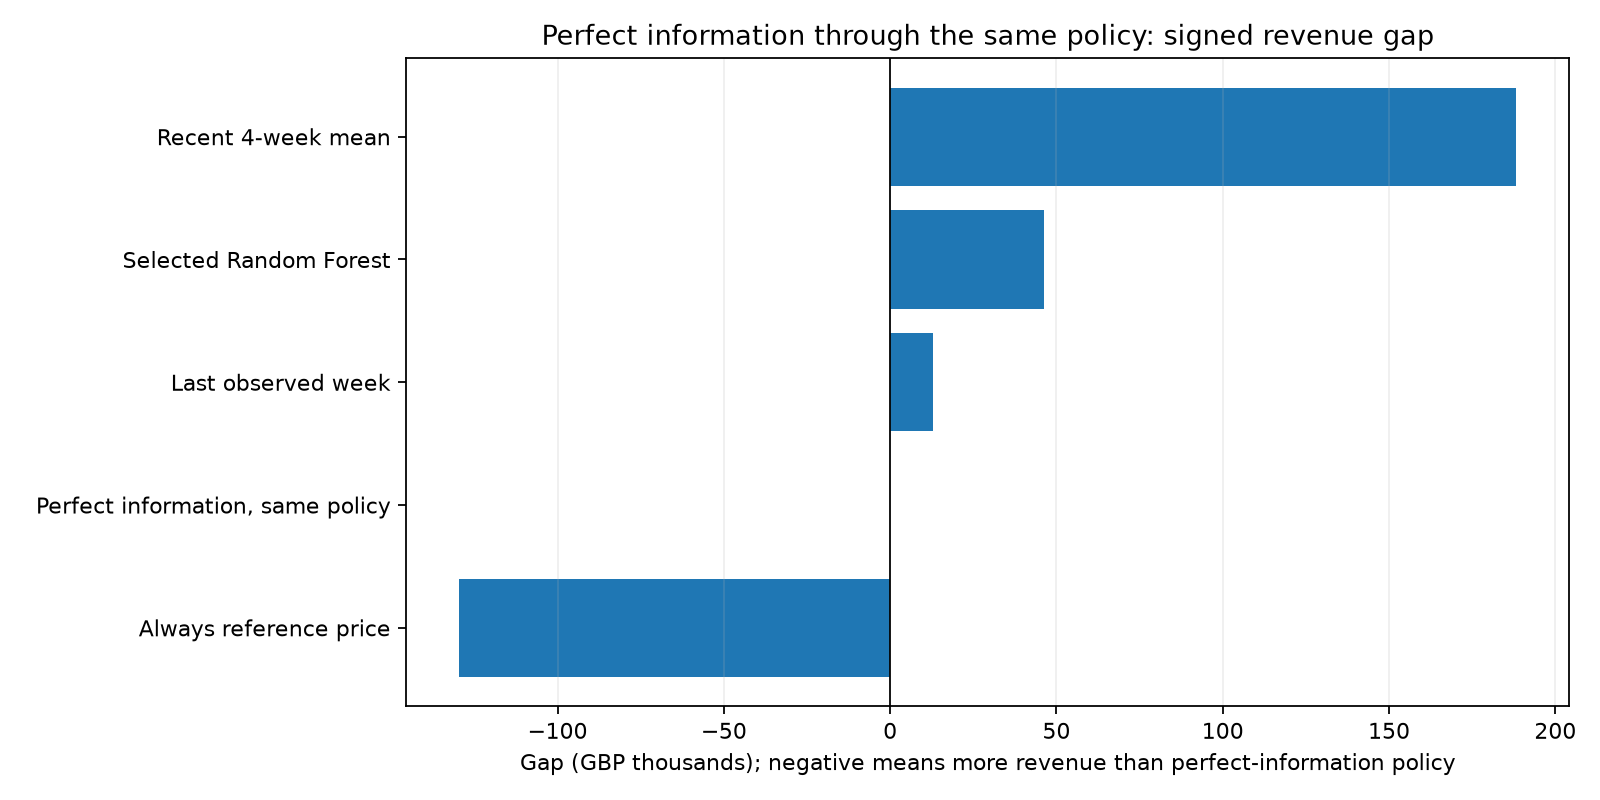

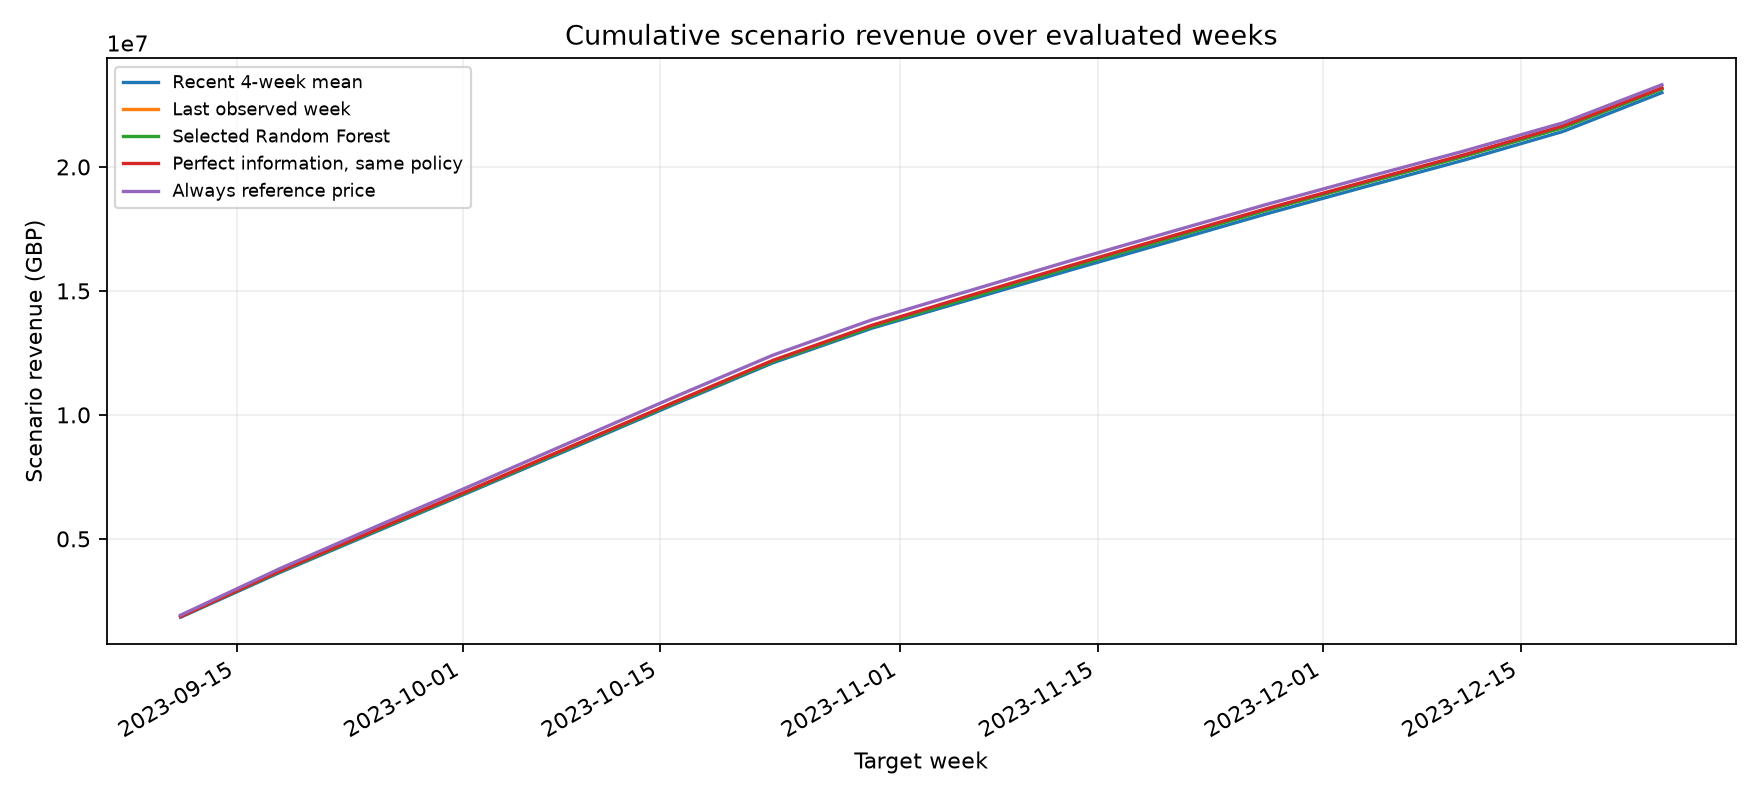

In [5]:
from IPython.display import Image, display
for name in ['forecast_h1.png', 'forecast_h4.png', 'revenue_sensitivity.png', 'same_policy_gap.png', 'revenue_cumulative.png']:
    display(Image(filename=str(output_dir / name)))


## Failure analysis
Inspect large errors by date and park; aggregate errors can conceal operationally important failures.

In [6]:
print('Largest model errors at each horizon:')
failures = __import__('pandas').read_csv(output_dir / 'failure_cases.csv')
print(failures.groupby('horizon_weeks', sort=True).head(3).to_string(index=False))


Largest model errors at each horizon:
terminal carpark_name target_week issue_date origin_week  horizon_weeks  actual_space_days  recent_mean_prediction  last_week_prediction  model_prediction  capacity_proxy_space_days training_last_target_week  training_rows  model_absolute_error  recent_mean_absolute_error  last_week_absolute_error
      T1     carpark1  2023-12-25 2023-12-25  2023-12-18              1              12963                 6670.50                8485.0       9462.419749                      17570                2023-12-18            688           3500.580251                     6292.50                    4478.0
      T1     carpark1  2023-10-30 2023-10-30  2023-10-23              1               9438                13018.00               12482.0      12706.163381                      17570                2023-10-23            560           3268.163381                     3580.00                    3044.0
      T1     carpark1  2023-11-06 2023-11-06  2023-10-30         